### Camera and Ray Construction

##### Objective: 
- Describe a model of a virtual camera in computer Graphics
- Describe how to construct rays casted from the camera through pixels

Algorithm for Ray Casting (psuedo):
- Assume we have the objects, the camera and the plane (representing the pixels) positioned in the scene
- For Every pixel p (on the plane):
    1.  Shoot a ray from the centre of projection through the pixel.
    2. Find the **closest** intersection with scene object.
    3. Calculate the color c at intersection point.
    4. Assign c to p.
```cpp
Image RayCast (Camera camera, Scene scene, int width, int height)
    Image image = new Image(width height);
    for (int i =0; i < width; i++){
        for (int j = 0; j < height; j++){
            // Geometric Calculation
            Ray ray = ConstructRayThroughPixel(camera, i , j);
            // Geometric Calculation
            Point point = FindIntersection(ray, scene);
            // Shading Calculation
            image[i][j] = getColor(scene, ray, hitP);
        }
    }
```

### Defining Camera Model

#### Camera model in the physical World:
- A closed boxed with a very small hole for light to get through
- The rays create a projected image of the scene on the backside of the box.
- The projected image is upside down and left to right.

#### The Camera model in Computer Graphics:
- Centre point of projection.
- The image is projected infront of the of the camera
- The centre point is also an origin point of coordinate system from which the image plane is defined.
- The x , y axis are defined as RIGHT and UP (respectively). 
- The z axis define the direction in which the camera is pointing towards.
    - Convention is that -z Axis is the direction of the scene.

#### The Ray projection from the Camera model:

Let $p_0$ be the centre of the camera in which a ray will be shot out.  
We can define the direction in which the ray will the plane and the image via (parametric): $$p_0 + t\vec{v}$$ where $\vec{v} = \frac{p-p_0}{|p-p_0|}$ this means $\vec{v}$ is normalised.

Let $F$ (Focal Length) be the distance between then image plane and the centre of projection $p_0$, this means that the centre pixel is located exactly $F$ from $p_0$, in the direction of the towards vector.  
This means that $$p_1 = p_0 + F\vec{v_{towards}}$$

$\text{If we know the width of the image and the number of pixels in each row is n, we can claculate the position of each pixel in the row}$
$\text{So starting at the centre pixel, we can choose to move right or left by using } \vec{v_{left}} \ \vec{v_{right}} \text{obtaining}$

$$ P_i = P_1 + i \cdot \frac{width}{N}\cdot \vec{v_{rightt}} \forall \ i \in  \left{\frac{-N-1}{2}, ..., \frac{N-1}{2}\right}$$

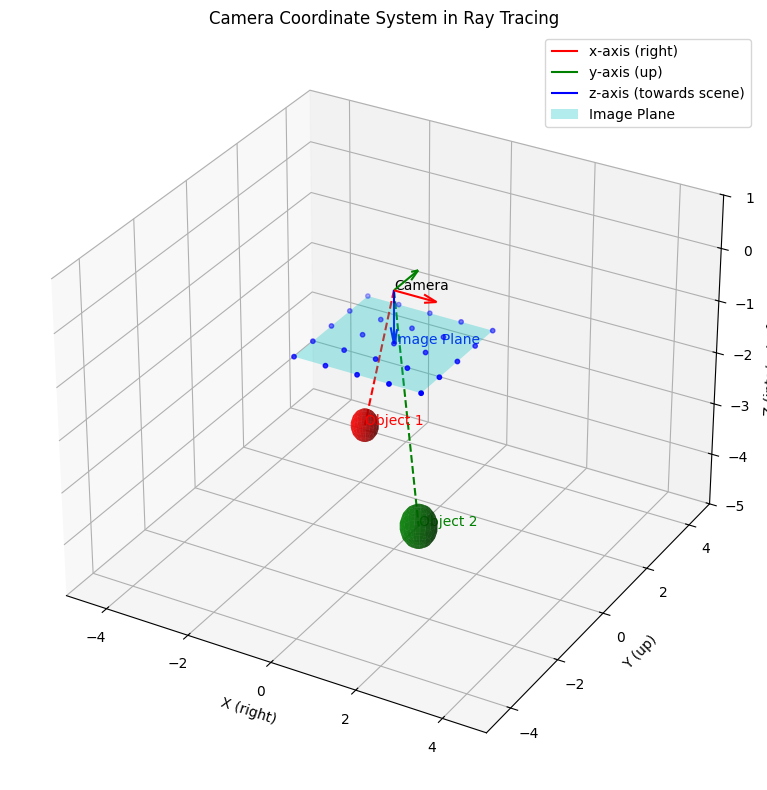

In [2]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from matplotlib.patches import Rectangle
import mpl_toolkits.mplot3d.art3d as art3d

def draw_camera_system():
    # Create figure and 3D axis
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Camera position (origin)
    camera_pos = np.array([0, 0, 0])
    
    # Draw camera coordinate system
    # x-axis (right)
    ax.quiver(camera_pos[0], camera_pos[1], camera_pos[2], 
              1, 0, 0, color='r', label='x-axis (right)')
    # y-axis (up)
    ax.quiver(camera_pos[0], camera_pos[1], camera_pos[2], 
              0, 1, 0, color='g', label='y-axis (up)')
    # z-axis (backward)
    ax.quiver(camera_pos[0], camera_pos[1], camera_pos[2], 
              0, 0, -1, color='b', label='z-axis (towards scene)')
    
    # Image plane (at z = -1)
    plane_z = -1
    plane_size = 1.5
    plane_x = np.linspace(-plane_size, plane_size, 2)
    plane_y = np.linspace(-plane_size, plane_size, 2)
    plane_X, plane_Y = np.meshgrid(plane_x, plane_y)
    plane_Z = np.ones_like(plane_X) * plane_z
    
    # Draw image plane
    ax.plot_surface(plane_X, plane_Y, plane_Z, alpha=0.3, color='cyan', label='Image Plane')
    
    # Visualize pixels on the image plane
    pixel_density = 5
    pixel_x = np.linspace(-plane_size, plane_size, pixel_density)
    pixel_y = np.linspace(-plane_size, plane_size, pixel_density)
    pixel_X, pixel_Y = np.meshgrid(pixel_x, pixel_y)
    pixel_Z = np.ones_like(pixel_X) * plane_z
    
    # Draw pixels as small points
    ax.scatter(pixel_X.flatten(), pixel_Y.flatten(), pixel_Z.flatten(), color='blue', s=10)
    
    # Add some scene objects (simple spheres)
    sphere1_center = np.array([-1, 0.5, -3])
    sphere1_radius = 0.3
    u, v = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
    x = sphere1_center[0] + sphere1_radius * np.cos(u) * np.sin(v)
    y = sphere1_center[1] + sphere1_radius * np.sin(u) * np.sin(v)
    z = sphere1_center[2] + sphere1_radius * np.cos(v)
    ax.plot_surface(x, y, z, color='red', alpha=0.7)
    
    sphere2_center = np.array([1, -0.7, -4])
    sphere2_radius = 0.4
    x = sphere2_center[0] + sphere2_radius * np.cos(u) * np.sin(v)
    y = sphere2_center[1] + sphere2_radius * np.sin(u) * np.sin(v)
    z = sphere2_center[2] + sphere2_radius * np.cos(v)
    ax.plot_surface(x, y, z, color='green', alpha=0.7)
    
    # Draw a few example rays from camera through pixels to objects
    # Ray to first sphere
    pixel_pos = np.array([0.3, 0.5, plane_z])
    ray_dir = sphere1_center - camera_pos
    ray_dir = ray_dir / np.linalg.norm(ray_dir)
    ax.plot([camera_pos[0], sphere1_center[0]], 
            [camera_pos[1], sphere1_center[1]], 
            [camera_pos[2], sphere1_center[2]], 'r--')
    
    # Ray to second sphere
    pixel_pos = np.array([-0.5, -0.3, plane_z])
    ray_dir = sphere2_center - camera_pos
    ray_dir = ray_dir / np.linalg.norm(ray_dir)
    ax.plot([camera_pos[0], sphere2_center[0]], 
            [camera_pos[1], sphere2_center[1]], 
            [camera_pos[2], sphere2_center[2]], 'g--')
    
    # Customize the plot
    ax.set_xlabel('X (right)')
    ax.set_ylabel('Y (up)')
    ax.set_zlabel('Z (into/out of scene)')
    ax.set_title('Camera Coordinate System in Ray Tracing')
    
    # Set equal aspect ratio
    max_range = np.array([
        plane_X.max()-plane_X.min(),
        plane_Y.max()-plane_Y.min(),
        10
    ]).max() / 2.0
    
    mid_x = (plane_X.max()+plane_X.min()) / 2
    mid_y = (plane_Y.max()+plane_Y.min()) / 2
    mid_z = (plane_Z.max()+plane_Z.min()) / 2
    
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(-5, 1)
    
    # Add legend
    ax.legend(loc='upper right')
    
    plt.tight_layout()
    plt.grid(True)
    
    # Annotate key elements
    ax.text(0, 0, 0, "Camera", color='black', fontsize=10)
    ax.text(-1, 0.5, -3, "Object 1", color='red', fontsize=10)
    ax.text(1, -0.7, -4, "Object 2", color='green', fontsize=10)
    ax.text(0, 0, plane_z, "Image Plane", color='blue', fontsize=10)
    
    return fig

# Call the function to create the visualization
fig = draw_camera_system()
plt.show()

### Image To Pixel Plane Conversion

If The width $W$ of the image is given and the number of pixels in each row $N$.
- To calculate each pixel in the row:  
$$P_1(centre\ point) + \frac{W}{N}$$
- To move right we use the RIGHT vector and multiply weighted propotions $\frac{W}{N}$ indexes of the number of pixels:  
$$
p_i = p_1 + i \cdot \frac{W}{N} \cdot \vec{v}_{\text{RIGHT}}, \quad \forall i \in \left\{ \frac{-(N+1)}{2}, \ldots, \frac{N-1}{2} \right\}
$$

Similarly If we know the hieght of the Image $H$ and the number of pixel in each column $M$.

- To calculate each pixel in the column:  
$$P_1(centre\ point) + \frac{H}{M}$$  
- To move up we use the UP vector to $\vec{v_up}$ and multiply weighted propotions $\frac{H}{M}$ indicies of the number of pixels: 
$$
p_i = p_1 + j \cdot \frac{H}{M} \cdot \vec{v}_{\text{UP}}, \quad \forall j \in \left\{ \frac{-(M+1)}{2}, \ldots, \frac{M-1}{2} \right\}
$$


#### Concluding:  
$$R(t) = p_0 + t\vec{v}$$ 
where 
$$ \vec{v} = \frac{p-p_0}{||p-p_0||}$$
where $$p - p_0 ~=~ F \cdot \vec{v_{towards}} + i \cdot \frac{W}{N} \cdot \vec{v}_{\text{RIGHT}} + j \cdot \frac{H}{M} \cdot \vec{v}_{\text{UP}}$$

### Image to Pixel Plane conversion (No Height & Width of Image)  

Suppose, we aren't provided the height or the width of the image but we know the opening angle of the camera $\theta$  

- Given the distance of camera to plane $F$ and trig. we can determine weidth and height of image: 

##### Horizontal  

$$tan(\theta_{horizontal}) = \frac{W}{2F}$$ 

$$ \therefore W = tan(\theta_{horizontal}) \cdot 2F$$  

##### Vertical  

$$\tan(\theta_{\text{vertical}}) = \frac{H}{2F}$$  

$$\therefore H = 2F \cdot \tan(\theta_{\text{vertical}})$$

In [ ]:
def ray_cast(camera, scene, width, height):
    """
    Ray casting implementation using nested for loops
    
    Args:
        camera: Camera object containing view parameters
        scene: Scene object containing all objects to render
        width: Width of the output image in pixels
        height: Height of the output image in pixels
        
    Returns:
        2D numpy array representing the rendered image
    """
    import numpy as np
    
    # Initialize empty image
    image = np.zeros((height, width, 3))  # 3 channels for RGB
    
    # Iterate through each pixel
    for i in range(width):
        for j in range(height):
            # Construct ray from camera through pixel (i,j)
            ray = construct_ray_through_pixel(camera, i, j)
            
            # Find intersection with scene objects
            hit_point = find_intersection(ray, scene)
            
            # Calculate color at intersection point
            if hit_point is not None:
                image[j, i] = get_color(scene, ray, hit_point)
    
    return image

In [ ]:
def ray_cast_vectorized(camera, scene, width, height):
    """
    Ray casting implementation using vectorized operations
    
    Args:
        camera: Camera object containing view parameters
        scene: Scene object containing all objects to render
        width: Width of the output image in pixels
        height: Height of the output image in pixels
        
    Returns:
        2D numpy array representing the rendered image
    """
    import numpy as np
    
    # Initialize empty image
    image = np.zeros((height, width, 3))  # 3 channels for RGB
    
    # Generate all pixel coordinates
    x, y = np.meshgrid(np.arange(width), np.arange(height))
    pixel_coords = np.stack((x.flatten(), y.flatten()), axis=1)
    
    # Vectorized ray construction
    rays = np.array([construct_ray_through_pixel(camera, i, j) for i, j in pixel_coords])
    
    # Vectorized intersection finding and color calculation
    hit_points = np.array([find_intersection(ray, scene) for ray in rays])
    colors = np.array([get_color(scene, ray, hit_point) if hit_point is not None else [0, 0, 0]
                      for ray, hit_point in zip(rays, hit_points)])
    
    # Reshape colors to form the image
    image = colors.reshape(height, width, 3)
    
    return image